PROJECT 1 
STOCK FINDER version1 (3 stocks)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
stocks = ["TCS.NS","INFY.NS","RELIANCE.NS"]

In [ ]:
stock_data={}                 
for stock in stocks:
    stock_data[stock]=yf.download(stock,start="2020-01-01",progress=False)

In [4]:
stock_data["TCS.NS"].head()

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2020-01-01,1866.113892,1880.146596,1854.405398,1866.458173,1354908
2020-01-02,1857.547852,1876.746243,1850.273183,1876.746243,2380752
2020-01-03,1894.567139,1913.808618,1863.014777,1863.014777,4655761
2020-01-06,1894.395020,1916.348290,1883.590525,1898.312214,3023209
2020-01-07,1899.043945,1906.619807,1880.060782,1894.437979,2429317


In [7]:
stock_data["TCS.NS"].shape

(1583, 5)

In [8]:
stock_data["TCS.NS"].isnull().sum()

Price   Ticker
Close   TCS.NS    0
High    TCS.NS    0
Low     TCS.NS    0
Open    TCS.NS    0
Volume  TCS.NS    0
dtype: int64

In [9]:
stock_data["TCS.NS"]["Close"].head()

Ticker,TCS.NS
Date,
2020-01-01,1866.113892
2020-01-02,1857.547852
2020-01-03,1894.567139
2020-01-06,1894.395020
2020-01-07,1899.043945


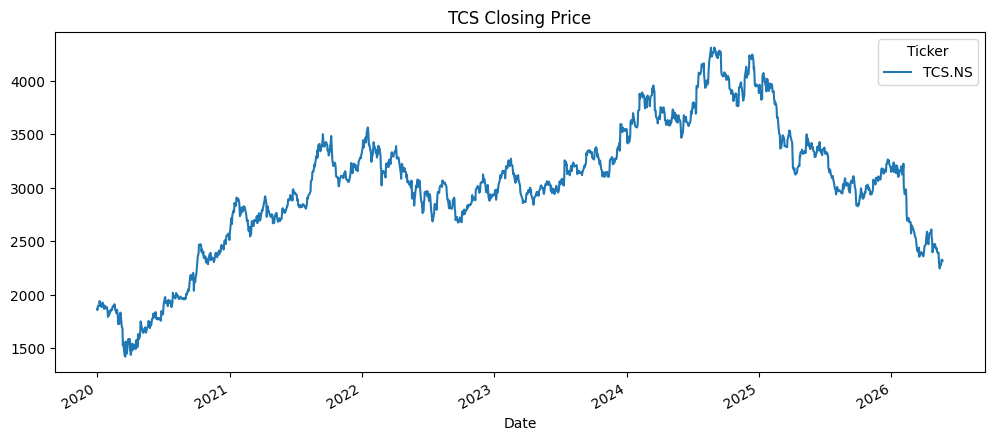

In [10]:
stock_data["TCS.NS"]["Close"].plot(figsize=(12,5))
plt.title("TCS Closing Price")
plt.show()

In [15]:
stock_data["TCS.NS"]["Daily_Return"]=stock_data["TCS.NS"]["Close"].pct_change()
stock_data["TCS.NS"][["Close","Daily_Return"]].head()

Price,Close,Daily_Return
Ticker,TCS.NS,
Date,,
2020-01-01,1866.113892,NaN
2020-01-02,1857.547852,-0.004590
2020-01-03,1894.567139,0.019929
2020-01-06,1894.395020,-0.000091
2020-01-07,1899.043945,0.002454


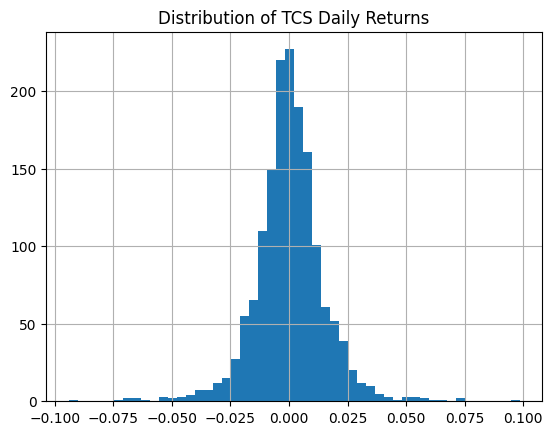

In [16]:
stock_data["TCS.NS"]["Daily_Return"].hist(bins=50)
plt.title("Distribution of TCS Daily Returns")
plt.show()

In [17]:
stock_data["TCS.NS"]["Daily_Return"].std()

np.float64(0.015151543243655925)

In [18]:
for stock in stocks:
    stock_data[stock]["Daily_Return"] = stock_data[stock]["Close"].pct_change()
    risk = stock_data[stock]["Daily_Return"].std()
    print(stock, "Risk =", risk)

TCS.NS Risk = 0.015151543243655925
INFY.NS Risk = 0.017445573104281423
RELIANCE.NS Risk = 0.01770457113812039


In [ ]:
for stock in stocks:
    close = stock_data[stock]["Close"]
    total_return = ((close.iloc[-1] / close.iloc[0]) - 1) * 100
    print(stock, "Return =", total_return)

TCS.NS Return = Ticker
TCS.NS    24.177847
dtype: float64
INFY.NS Return = Ticker
INFY.NS    85.500719
dtype: float64
RELIANCE.NS Return = Ticker
RELIANCE.NS    100.570346
dtype: float64


In [22]:
summary = []
for stock in stocks:
    close = stock_data[stock]["Close"]
    total_return = ((close.iloc[-1].item() / close.iloc[0].item()) - 1) * 100
    risk = stock_data[stock]["Daily_Return"].std().item() * 100
    summary.append([stock, total_return, risk])

summary_df = pd.DataFrame(summary,columns=["Stock", "Return (%)", "Risk (%)"])
summary_df

,Stock,Return (%),Risk (%)
0,TCS.NS,24.177847,1.515154
1,INFY.NS,85.500719,1.744557
2,RELIANCE.NS,100.570346,1.770457


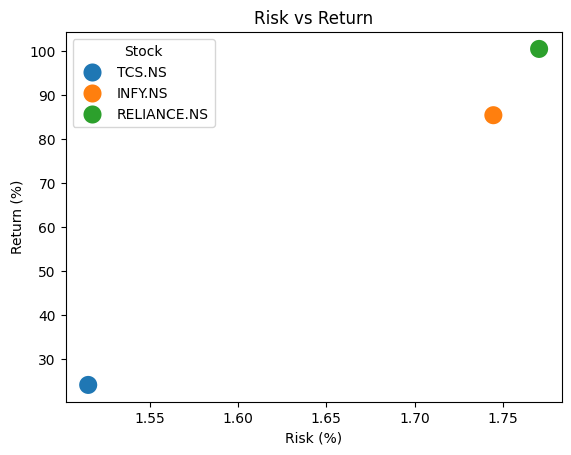

In [24]:
sns.scatterplot(data=summary_df,x="Risk (%)",y="Return (%)",hue="Stock",s=200)
plt.title("Risk vs Return")
plt.show()

In [25]:
summary_df["Score"] = summary_df["Return (%)"] / summary_df["Risk (%)"]
summary_df

,Stock,Return (%),Risk (%),Score
0,TCS.NS,24.177847,1.515154,15.957349
1,INFY.NS,85.500719,1.744557,49.009980
2,RELIANCE.NS,100.570346,1.770457,56.804734


In [27]:
summary_df.sort_values(by="Score",ascending=False)

,Stock,Return (%),Risk (%),Score
2,RELIANCE.NS,100.570346,1.770457,56.804734
1,INFY.NS,85.500719,1.744557,49.009980
0,TCS.NS,24.177847,1.515154,15.957349


In [36]:
ranking_df = summary_df.sort_values(by="Score",ascending=False).reset_index(drop=True)
ranking_df.index = range(1, len(ranking_df)+1)
ranking_df.index.name="Rank"
ranking_df

,Stock,Return (%),Risk (%),Score
Rank,,,,
1,RELIANCE.NS,100.570346,1.770457,56.804734
2,INFY.NS,85.500719,1.744557,49.009980
3,TCS.NS,24.177847,1.515154,15.957349


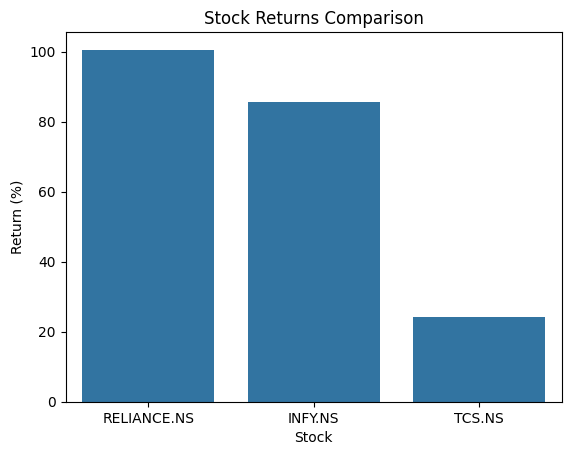

In [37]:
sns.barplot(data=ranking_df,x="Stock",y="Return (%)")
plt.title("Stock Returns Comparison")
plt.show()

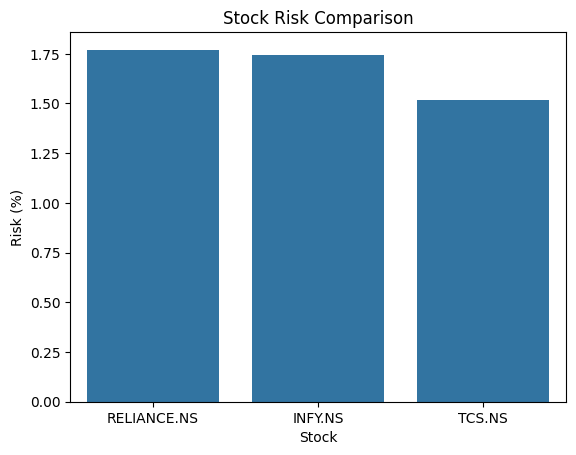

In [38]:
sns.barplot(data=ranking_df,x="Stock",y="Risk (%)")
plt.title("Stock Risk Comparison")
plt.show()